In [1]:
import pickle
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np
from sklearn.svm import SVC
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns

In [2]:
# data_file_path = "../data/20250512/processed/ishii_merged.pkl"
data_file_path = Path("../../data/20250604/processed/20250604_1_ishii_ica_epochs.pkl")
# data_file_path = "../../data/bcidatasetIV2a/processed/merged.pkl"

In [3]:
# pickleのEEGデータを読み込む
with open(data_file_path, 'rb') as f:
    data = pickle.load(f)

epochs = data['epochs'] # エポックデータ
epochs_list = epochs.get_data()  # エポックデータをリスト形式で取得
labels = data['labels']  # ラベル
# drop_indices = data['drop_indices']  # 除外されたエポックのインデックス
fs = epochs.info['sfreq']  # サンプリング周波数

In [4]:
ch_map = list(enumerate(epochs.info["ch_names"]))
ch_map

[(0, 'Fp1'),
 (1, 'Fz'),
 (2, 'F3'),
 (3, 'F7'),
 (4, 'FT9'),
 (5, 'FC5'),
 (6, 'FC1'),
 (7, 'C3'),
 (8, 'T7'),
 (9, 'TP9'),
 (10, 'CP5'),
 (11, 'CP1'),
 (12, 'Pz'),
 (13, 'P3'),
 (14, 'P7'),
 (15, 'O1'),
 (16, 'Oz'),
 (17, 'O2'),
 (18, 'P4'),
 (19, 'P8'),
 (20, 'TP10'),
 (21, 'CP6'),
 (22, 'CP2'),
 (23, 'Cz'),
 (24, 'C4'),
 (25, 'T8'),
 (26, 'FT10'),
 (27, 'FC6'),
 (28, 'FC2'),
 (29, 'F4'),
 (30, 'F8'),
 (31, 'Fp2'),
 (32, 'AF7'),
 (33, 'AF3'),
 (34, 'AFz'),
 (35, 'F1'),
 (36, 'F5'),
 (37, 'FT7'),
 (38, 'FC3'),
 (39, 'C1'),
 (40, 'C5'),
 (41, 'TP7'),
 (42, 'CP3'),
 (43, 'P1'),
 (44, 'P5'),
 (45, 'PO7'),
 (46, 'PO3'),
 (47, 'POz'),
 (48, 'PO4'),
 (49, 'PO8'),
 (50, 'P6'),
 (51, 'P2'),
 (52, 'CPz'),
 (53, 'CP4'),
 (54, 'TP8'),
 (55, 'C6'),
 (56, 'C2'),
 (57, 'FC4'),
 (58, 'FT8'),
 (59, 'F6'),
 (60, 'AF8'),
 (61, 'AF4'),
 (62, 'F2')]

In [5]:
use_chs = ["C5","C1","C2","C6","CP3","CP4"]
use_chs_idx = [epochs.info["ch_names"].index(ch) for ch in use_chs]
use_chs_idx

[40, 39, 56, 55, 42, 53]

In [6]:
# 例: axis=1で2, 4, 7番目の要素のみを選択する場合
# selected_indices = [2, 4, 7]
# epochs_selected = epochs_list[:, selected_indices, :]
# print(f"元の形状: {epochs_list.shape}")
# print(f"選択後の形状: {epochs_selected.shape}")

# または、チャンネル名で指定する場合
use_chs = ["C5","C1","C2","C6","CP3","CP4"]
use_chs_idx = [epochs.info["ch_names"].index(ch) for ch in use_chs]
use_chs_idx

[40, 39, 56, 55, 42, 53]

In [7]:
# labelsが9999のものを除外する
valid_indices = np.where(labels != 9999)[0]
# epochs_list = epochs_list[valid_indices]
labels = labels[valid_indices]

In [8]:
epochs_list.shape

(60, 63, 12501)

In [9]:
labels.shape

(60,)

In [10]:
# 1チャンネルのデータをDFTしてバンドパスパワーを計算
def calc_spectrum(data, band_count, fs):
    n = len(data)
    freq = np.fft.fftfreq(n, 1/fs)
    spectrum = np.fft.fft(data)
    # 1Hz-40Hzまでの4Hzごとのバンドパスパワーを計算
    band_lower = 0
    band_upper = 40
    band_powers = [None] * band_count
    for i in range(band_count):
        band = band_lower+i*(band_upper-band_lower)/band_count, band_lower+(i+1)*(band_upper-band_lower)/band_count
        band_power = np.sum(np.abs(spectrum[(freq >= band[0]) & (freq < band[1])])**2)
        band_powers[i] = band_power
    
    # band_powersの中にNoneがないことをassert
    # assert all([v is not None for v in band_powers]), "Some band powers are None"
    assert all(band_powers), "Some band powers are None"
    return band_powers

In [11]:
# 時間方向を6等分し、それぞれのウィンドウでFFTを計算する関数
def calc_windowed_spectrum(data, band_count, fs, window_count=6):
    n = len(data)
    window_size = n // window_count
    all_band_powers = []
    
    for i in range(window_count):
        # ウィンドウの開始位置と終了位置を計算
        start_idx = i * window_size
        end_idx = (i + 1) * window_size if i < window_count - 1 else n
        
        # 現在のウィンドウのデータを取得
        window_data = data[start_idx:end_idx]
        
        # 現在のウィンドウでFFTを計算
        window_band_powers = calc_spectrum(window_data, band_count, fs)
        
        # 結果を追加
        all_band_powers.extend(window_band_powers)
    
    return all_band_powers

In [12]:
e0 = epochs_list[0, :, :]
e0c0 = epochs_list[0, 0, :]
e0c0

array([-9.30949766e-06, -9.46138806e-06, -9.58895937e-06, ...,
       -3.94677566e-06, -3.60453253e-06, -3.26022334e-06])

In [14]:
calc_windowed_spectrum(e0c0, 10, fs, 6)

[1.242535434369619e-05,
 1.0502383360596686e-05,
 1.4796016375722655e-06,
 5.462735041935854e-06,
 4.7358764067470585e-06,
 8.18166113383729e-06,
 6.222603371592294e-06,
 2.5125538212769196e-06,
 2.0291127348277655e-06,
 2.8060544792405792e-06,
 4.769416837864079e-05,
 2.1792921153438558e-05,
 1.0027314516926653e-05,
 1.0504876281160157e-05,
 4.9205039658280455e-06,
 4.331992593991049e-06,
 8.901508188773155e-06,
 4.977574862009146e-06,
 3.897835454323283e-06,
 5.184962074495201e-06,
 4.5969957541769094e-05,
 1.0090804831398423e-05,
 6.056369702511395e-06,
 8.559708958297714e-06,
 2.6357008296091924e-06,
 6.918364873274471e-06,
 1.19813778839859e-05,
 2.2954091776450213e-06,
 3.2897223302473653e-06,
 4.210327348128307e-06,
 2.2126723446526438e-05,
 5.788705562404256e-06,
 5.572262019950528e-06,
 5.08431039876628e-06,
 1.0781039116787421e-05,
 1.4746787948709924e-05,
 9.023809831181437e-06,
 8.778222261292554e-06,
 1.285116577053922e-07,
 6.164636587214065e-06,
 3.498849609599876e-05,
 

In [15]:
# epochs_list[0]の各チャンネルのDFTを計算
def calc_spectrum_all_channels(epoch, band_count, fs, window_count=6):
    n_channels = epoch.shape[0]
    # 各チャンネルにつき、band_count × window_count の特徴量を格納するように変更
    band_powers = np.zeros((n_channels, band_count * window_count))
    for i in range(n_channels):
        band_powers[i] = calc_windowed_spectrum(epoch[i, :], band_count, fs, window_count)
    return band_powers

In [16]:
epochs_list

array([[[-9.30949766e-06, -9.46138806e-06, -9.58895937e-06, ...,
         -3.94677566e-06, -3.60453253e-06, -3.26022334e-06],
        [-6.61819783e-06, -6.67719987e-06, -6.72905247e-06, ...,
         -4.93273802e-06, -4.60791761e-06, -4.26894912e-06],
        [-1.14789266e-05, -1.14936513e-05, -1.15076565e-05, ...,
         -7.45696650e-06, -7.30558514e-06, -7.13490628e-06],
        ...,
        [-8.68024392e-06, -8.88847776e-06, -9.08003784e-06, ...,
         -7.44699476e-06, -7.11538511e-06, -6.76824569e-06],
        [ 7.86079327e-06,  7.66818884e-06,  7.43821140e-06, ...,
         -5.81038970e-06, -5.01818565e-06, -4.21080287e-06],
        [-4.35543682e-06, -4.40796432e-06, -4.45664434e-06, ...,
         -5.51612633e-06, -5.00906389e-06, -4.48585655e-06]],

       [[-4.64347313e-06, -4.64497821e-06, -4.66000783e-06, ...,
         -3.24555059e-06, -3.00362235e-06, -2.74540713e-06],
        [ 5.66985197e-06,  5.74854965e-06,  5.79338440e-06, ...,
         -1.77540176e-06, -1.79361111e

In [23]:
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
import multiprocessing

print(use_chs)
band_count = 10
window_count = 3

time_start = int(fs)
time_end = time_start+int(fs*3)

# 特徴量の次元を更新（window_count倍に）
# all_epochs_band_powers = np.zeros((epochs_list.shape[0], epochs_list.shape[1], band_count * window_count))
all_epochs_band_powers = np.zeros((epochs_list.shape[0], 63, band_count * window_count))

# 各エポックを処理する関数
def process_epoch(i):
    # return calc_spectrum_all_channels(epochs_list[i, use_chs_idx, :], band_count, fs, window_count)
    return calc_spectrum_all_channels(epochs_list[i, :, time_start:time_end], band_count, fs, window_count)

# 使用するCPUコア数を設定（-1は全コアを使用）
n_jobs = multiprocessing.cpu_count()
print(f"使用するCPUコア数: {n_jobs}")

# tqdmでプログレスバーを表示しながら並列処理
results = Parallel(n_jobs=n_jobs, verbose=0)(
    delayed(process_epoch)(i) for i in tqdm(range(epochs_list.shape[0]), desc='エポック処理中')
)

# 結果を配列に格納
for i, result in enumerate(results):
    all_epochs_band_powers[i] = result

print(all_epochs_band_powers)
all_epochs_band_powers.shape

['C5', 'C1', 'C2', 'C6', 'CP3', 'CP4']
使用するCPUコア数: 8


エポック処理中:   0%|          | 0/60 [00:00<?, ?it/s]

[[[9.96926312e-05 2.60328775e-05 1.20472378e-05 ... 9.07373748e-06
   4.48683712e-06 7.08162969e-06]
  [1.00870844e-04 2.57521189e-05 1.63642226e-05 ... 9.54613004e-06
   6.09075387e-06 9.92428007e-06]
  [8.96367022e-05 2.83761516e-05 1.60819605e-05 ... 9.76586510e-06
   9.96579605e-06 8.81990857e-06]
  ...
  [2.71778157e-05 1.32749009e-05 6.82009127e-06 ... 1.03290433e-05
   2.36940252e-06 2.07722132e-06]
  [2.84455428e-04 1.60247264e-05 2.36476155e-05 ... 2.14092990e-05
   1.17625380e-05 2.95146354e-05]
  [1.07227358e-04 2.20828445e-05 1.42142537e-05 ... 1.22915347e-05
   7.52232369e-06 1.03024715e-05]]

 [[1.63096908e-04 1.41455440e-05 4.46840144e-06 ... 4.00680324e-07
   5.08876915e-06 7.82065897e-06]
  [1.69173931e-04 2.02049467e-05 1.13511260e-05 ... 2.19240701e-06
   4.70972046e-06 5.78278395e-06]
  [1.76989201e-04 1.53299336e-05 1.13771008e-05 ... 3.83562795e-06
   4.37345138e-06 5.88297670e-06]
  ...
  [1.41033360e-04 1.20646517e-05 8.35234493e-06 ... 1.62545697e-05
   3.56624

(60, 63, 30)

In [ ]:
# all_epochs_band_powersをpickleで保存
# data_file_pathと同じディレクトリにサフィックスをつけて保存
output_file_path = data_file_path.parent / (data_file_path.stem + '_band_powers.pkl')
with open(output_file_path, 'wb') as f:
    pickle.dump({
        'band_powers': all_epochs_band_powers,
        'labels': labels,
        'fs': fs,
        'use_chs': use_chs,
        'use_chs_idx': use_chs_idx
    }, f)
print(f"特徴量を保存しました: {output_file_path}")

In [50]:
# 特徴量を2次元配列に変換（サンプル数×特徴量）
# 各チャンネルにつき10個のバンドパワー × 6個のウィンドウ
# つまり、チャンネル数 × 10 × 6 の特徴量を持つデータに変換
X = all_epochs_band_powers.reshape(all_epochs_band_powers.shape[0], -1)
print(f"特徴量のshape: {X.shape}")
print(f"ラベルのshape: {labels.shape}")

# トレーニングデータとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.3, random_state=42, stratify=labels)

特徴量のshape: (60, 90)
ラベルのshape: (60,)


In [51]:
# 特徴量のスケーリング
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
# SVMモデルの作成と学習
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train_scaled, y_train)

# テストデータで予測
y_pred = svm.predict(X_train_scaled)

# 評価
print("分類レポート:")
# print(classification_report(y_test, y_pred))# ラベルの分布を確認
print(classification_report(y_train, y_pred))# ラベルの分布を確認
unique_labels, counts = np.unique(labels, return_counts=True)
print("ラベルの分布:")
for label, count in zip(unique_labels, counts):
    print(f"ラベル {label}: {count}個")

分類レポート:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        21

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42

ラベルの分布:
ラベル 1: 30個
ラベル 2: 30個


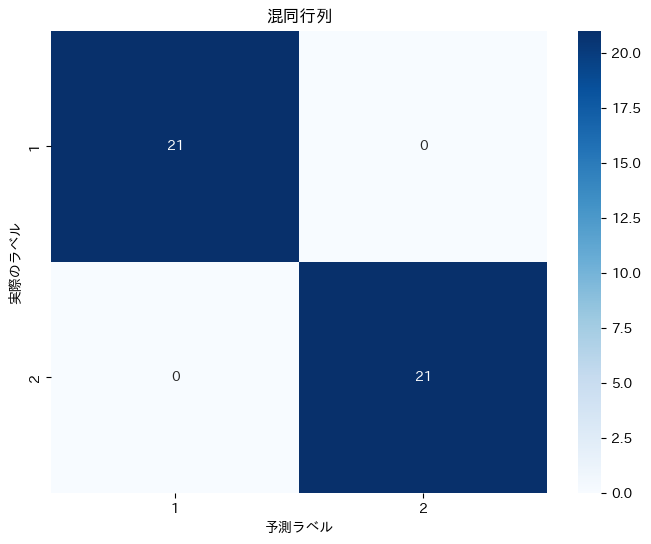

In [53]:
# 混同行列の表示
cm = confusion_matrix(y_train, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=unique_labels, 
           yticklabels=unique_labels)
plt.xlabel('予測ラベル')
plt.ylabel('実際のラベル')
plt.title('混同行列')
plt.show()

クロスバリデーションスコア: [0.6  0.6  0.25 0.75 0.5  0.75 0.25 0.5  0.5  0.5 ]
平均精度: 0.5200 ± 0.1631


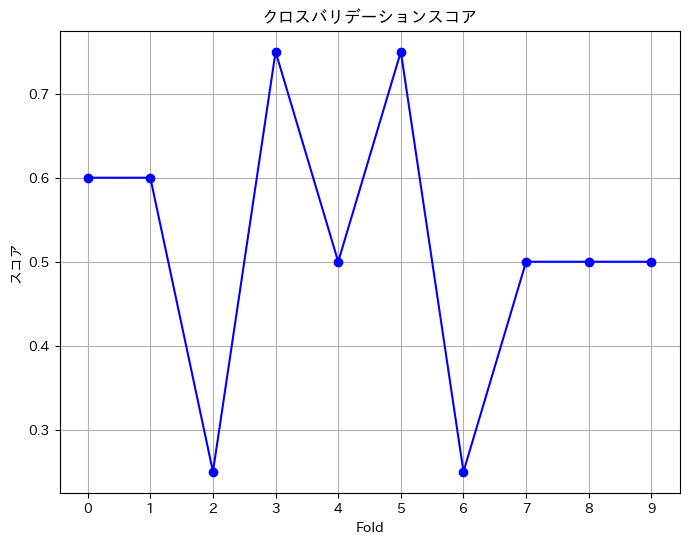

In [54]:
# クロスバリデーションで評価
cv_scores = cross_val_score(svm, X_train_scaled, y_train, cv=10)
print(f"クロスバリデーションスコア: {cv_scores}")
print(f"平均精度: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
# クロスバリデーションの結果をプロット
plt.figure(figsize=(8, 6))
plt.plot(cv_scores, marker='o', linestyle='-', color='b')
plt.title('クロスバリデーションスコア')
plt.xlabel('Fold')
plt.ylabel('スコア')
plt.xticks(range(len(cv_scores)))
plt.grid()
plt.show()

In [55]:
# ハイパーパラメータチューニング
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear', 'poly']
}

grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=10, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f"最適パラメータ: {grid_search.best_params_}")
print(f"最高スコア: {grid_search.best_score_:.4f}")


最適パラメータ: {'C': 0.1, 'gamma': 0.1, 'kernel': 'poly'}
最高スコア: 0.5950


最適モデルのクロスバリデーションスコア: [0.4  0.8  0.5  0.25 0.5  1.   0.5  0.5  0.75 0.75]
最適モデルの平均精度: 0.5950 ± 0.2115
最適モデルの分類レポート:
              precision    recall  f1-score   support

           1       0.30      0.33      0.32         9
           2       0.25      0.22      0.24         9

    accuracy                           0.28        18
   macro avg       0.28      0.28      0.28        18
weighted avg       0.27      0.28      0.28        18



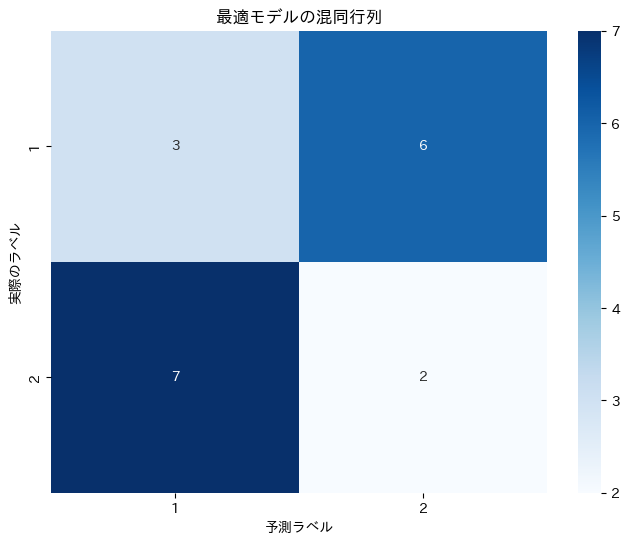

In [56]:
# 最適なモデルで評価
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test_scaled)

# 最適なモデルのCVスコアを計算
best_cv_scores = cross_val_score(best_svm, X_train_scaled, y_train, cv=10)
print(f"最適モデルのクロスバリデーションスコア: {best_cv_scores}")
print(f"最適モデルの平均精度: {best_cv_scores.mean():.4f} ± {best_cv_scores.std():.4f}")

print("最適モデルの分類レポート:")
print(classification_report(y_test, y_pred_best))

# 混同行列の表示
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
           xticklabels=unique_labels, 
           yticklabels=unique_labels)
plt.xlabel('予測ラベル')
plt.ylabel('実際のラベル')
plt.title('最適モデルの混同行列')
plt.show()